**Fundamentos de machine learning (ML)**

## Introdução prática com sklearn

Neste notebook vamos aprender:
- Conceitos fundamentais de ML
- Entendimento do dataset
- Pré - processamento
- Divisao treino/teste
- Treinamento de modelos
- Avaliação de desempenho

Vamos começar fazendo a importação das bibliotecas

##O que é machine learning?

ML é o ramo da inteligência artificial que desenvolve técnicas para que o computadores possam aprender com dados e melhorar seu desempenho em alguma tarefa ao longo do tempo, sem serem explicitamente programados para cada situação.

Formalmente, segundo Tom Mitchell (1997):

"Um programa de computador aprende com a experiência E em relação a alguma classe de tarefas T e medida de desempenho P, se seu desempenho em T, medido por P, melhora com a experiência E."



## 1.2 Tipos de Aprendizado

| Tipo | Descrição | Exemplos |
|------|-----------|----------|
| **Supervisionado** | Dados rotulados (entrada + saída esperada) | Classificação, Regressão |
| **Não supervisionado** | Dados não rotulados (apenas entradas) | Clusterização, Redução de dimensionalidade |
| **Por reforço** | Agente interage com ambiente e recebe recompensas | Jogos, Robótica |
| **Semi-supervisionado** | Mistura de rotulados e não rotulados | Classificação com poucos rótulos |

Neste notebook, focaremos em **aprendizado supervisionado**, que é a base para a maioria das aplicações práticas.

## 1.3 Conceitos Fundamentais

- **Instância (ou amostra):** cada linha dos dados.
- **Feature (atributo):** variável de entrada (coluna).
- **Target (rótulo):** variável que queremos prever.
- **Modelo:** representação matemática que mapeia features → target.
- **Treinamento:** processo de ajustar os parâmetros do modelo aos dados.
- **Generalização:** capacidade do modelo de performar bem em dados não vistos.
- **Overfitting:** modelo se ajusta demais aos dados de treino, perdendo generalização.
- **Underfitting:** modelo é muito simples para capturar a complexidade dos dados.



## 1.4 Trade-off Viés-Variancia
- Viés(bias): erro devido a suposições errôneas no algoritmo. Alto viés -> underfitting
- Variância(variance) : Erro devido a sensibilidade a flutuações nos dados de treino. Alta variância -> Overfitting

O objetivo é encontrar um equilivrio que minimize o erro total ( erro = vies² + variancia + erro irredutível)



## Entendendo o dataset
Antes de começarmos a modelagem, é crucial conhecer os dados. O EDA é a etapa que nos permite identificar padrões, anomalias, relacionamentos, orientando no pre-processamento

### Nessa aula vamos trabalhar com 3 conjuntos de dados clássicos :
- Iris (classificação de flores) : Pequeno, balanceado, todas as features numéricas
- California Housing( regressão de preços de imagens): Médio porte, features numericas
- Titanic (classificação de sobrevivencia) : Contem dados ausentes e variáveis categóricas


In [1]:
# Importações iniciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, fetch_california_housing

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
np.random.seed(42)

In [2]:
# Carregando datasets
iris = load_iris()
X_iris = iris.data #Definindo um X e y
y_iris = iris.target #Definindo a variavel alvo
feature_names_iris = iris.feature_names #Pegando o nome das features
target_names_iris = iris.target_names# Pegando o nome da variavel alvo

#Nesse caso nao temos o target_name, pois é um exemplo de classificação (sim ou nao)
housing = fetch_california_housing()
X_housing = housing.data
y_housing = housing.target
feature_names_housing = housing.feature_names

titanic = sns.load_dataset('titanic')

## Seleção de features
Nem todas as features são igualmente proporcionais. Selecionar as relevantes ajudam :
 - Reduzir o overfitting
 - Melhorara a interpretabilidade
 - Diminuir tempo de treinamento
 - Evitar a maldição da dimensionalidade

Métodos:
- Filtros : Baseados em estatísticas univariadas ( correlação, informação mútua, ANOVA);
- Wrappers : Usam um modelo para avaliar subconjuntos( RFE - Recursive Feature Elimination)
- Embedded : a seleção é feita durante o treinamento ( Regularização, L1, importancia em arvores)



In [3]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier

#O dataset Iris contem 4 features : Sepal lenght, sepal widht, petal lenght, petal width

# #xemplo com Iris : Selecionar as 2 melhores features com ANOVA
selector = SelectKBest(f_classif, k=2)
X_selected = selector.fit_transform(X_iris, y_iris)
print('Features selecionadas (índices):', selector.get_support(indices=True))
print('Scores:', selector.scores_)

# Usando informação mútua
selector_mi = SelectKBest(score_func=mutual_info_classif, k=2)
X_selected_mi = selector_mi.fit_transform(X_iris, y_iris)
print('Scores MI:', selector_mi.scores_)

# RFE com Random Forest
rf = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=2)
rfe.fit(X_iris, y_iris)
print('Ranking das features:', rfe.ranking_)

Features selecionadas (índices): [2 3]
Scores: [ 119.26450218   49.16004009 1180.16118225  960.0071468 ]
Scores MI: [0.5113651  0.29942431 0.99257309 0.98564251]
Ranking das features: [2 3 1 1]


O que esse resultado nos taz ?

1. O f_classic usa ANOVA F-value, que mede:

  O quando cada feature separa bem as classes
  
  **Quanto maior o score -> Melhor a separação entre as espécies**

Ou seja, de acordo com o nosso resultado as duas maiores sao de indice 2 e 3.

Conclusao: As medidas da pétala são muito mais discriminativas do que as da sépala.

-> Lembrando que o INDICE COMEÇA EM 0


2. SelectKBest com Informação Mutua:
  Mede : Quanto conhecer a feature reduz a incerteza sobre a classe.
  **Como no exemplo acima, quanto maior o score, melhor.**

3. RFE:
  No rfe : ranking = 1 -> Feature selecionada
           Ranking maior = Menos importante
  Features 1 e dao sao mais importntes


## Escalonamento : Normalização e padronização

Muitos algoritmos (KNN, SVM, regressão com regularização) são sensíveis a escala das features. O escalonamento coloca todas as features em uma escala comparável.

1. **Normalização (min-max scalling) :**
 $$
X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}
$$

Resulta em valores entre 0 e 1. Útil quando os dados não seguem distribuição normal e para redes neurais.




2. **Padronização (Standard Scaling):**
$$
X_{std} = \frac{X - \mu}{\sigma}
$$
Resulta em média 0 e desvio padrao 1. É a escolha para a maioria dos modelos.

3. **Robust Scalling :**
  Usa mediana e IQR, sendo robusto a outliers.




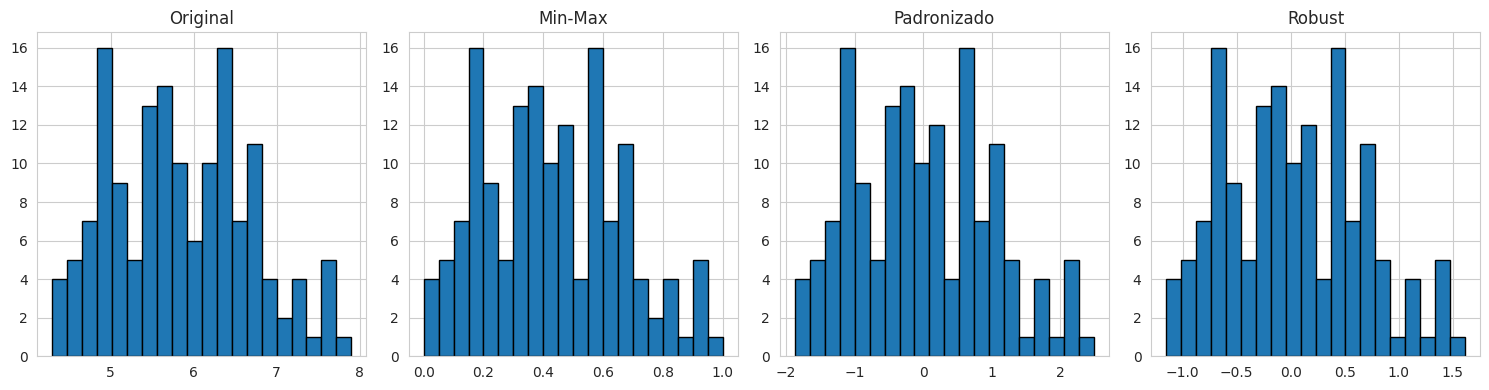

In [4]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

#Comparação no IRIs

#Normalização
scaler_mm = MinMaxScaler()
X_iris_mm = scaler_mm.fit_transform(X_iris)

#Padronziação
scaler_std = StandardScaler()
X_iris_std = scaler_std.fit_transform(X_iris)

#Robust
scaler_robust = RobustScaler()
X_iris_rob  = scaler_robust.fit_transform(X_iris)

# Visualização da primeira feature
plt.figure(figsize=(15,4))
plt.subplot(1,4,1)
plt.hist(X_iris[:,0], bins=20, edgecolor='k')
plt.title('Original')
plt.subplot(1,4,2)
plt.hist(X_iris_mm[:,0], bins=20, edgecolor='k')
plt.title('Min-Max')
plt.subplot(1,4,3)
plt.hist(X_iris_std[:,0], bins=20, edgecolor='k')
plt.title('Padronizado')
plt.subplot(1,4,4)
plt.hist(X_iris_rob[:,0], bins=20, edgecolor='k')
plt.title('Robust')
plt.tight_layout()
plt.show()

Entendimento dos gráficos:
**1. Original:**

  Valores reais das features: escala natural, media ~= 5.8, distribuição ja é aproximadamente normal

**2. MinMaxScaler:**

  TOdos os valores ficam entre 0 e 1, a forma da distribuição nao muda, apenas a escala é comprimida

  OBS : MixMax preserva a proporção relativa mas é sensivel a outliers ( se existir um valor extremo, ele 'achata' todo o resto.)

**3. StandardScaler(Padronização):**

  Média vira 0, Desvio padrao vira 1, valores passam a girar em torno de zero, podem existir valores negativos

  Interpretação : Agora os dados estão em escalas estatísticas, não física

**4. RobustScaler**

  Onde IQR : intervalo interquantil (Q3 - Q1)

  Usa mediana em vez de média, usa IQR em vez de desvio padrão, menos sensivel a outliers

  -> Parecido com StandardScaler, mas sofre menos influencias de valores extremos

## Pipeline e Column Transformers

**Pipeline** encadeia transformações e um estimador, garantindo que as mesmas transformações sejam aplicadas consistentemente nos dados de treino e teste, e facilitando a validação cruzada

**Column transformer** permite aplicar transformações diferentes a diferentes colunas ( ex: padronizações numericas, one-hot em categorias)

Exemplificando no dataset do titanic:



In [5]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

#Definindo as features
features_numericas = ['age', 'fare', 'pclass'] #Pclass como um numero ordinal
features_categoricas = ['sex', 'embarked']

#Transformadores
transformador_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')), #Trata dados faltantes como a media, ou seja, serao preenchidos com amedia
    ('scaler', StandardScaler())
])

transformador_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy = 'constant', fill_value = 'missing')), #Trata dados faltantes como missing, contant =
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

#Column Transformer
preprocessor = ColumnTransformer([
    ('num', transformador_numerico, features_numericas),
    ('cat', transformador_categorico, features_categoricas)
])

#Pipe - pipeline completo
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state = 42))
])

#Preparando dados(usando o titanic original com algumas colunas)
X_titanic = titanic[['pclass','sex', 'age', 'fare', 'embarked']]
y_titanic = titanic['survived']

#Treinando
pipe.fit(X_titanic, y_titanic)

print(f'Acuracia no treino: {pipe.score(X_titanic, y_titanic)}')

Acuracia no treino: 0.9775533108866442


Algumas vantasgens do pipeline é que ele pode ser usado diretamente em 'cross_val_score', 'grid search', evitnado vazamento de dados

## Divisao dos dados e Validação cruzada

### Treino, teste e validação

Para avaliar um modelo de forma honesta, precisamos separar uma parte dos dados que NUNCA será usada durante o desenvolvimento (conjunto de teste). O conjunto de treino é usado para ajustar o modelo, e o de validação (opcional) para ajustar os hiperparâmetros.

In [12]:
from sklearn.model_selection import train_test_split

#Divisao simples : 70% treino, 30% teste
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size = 0.3, random_state = 42,
                                                    stratify = y_iris) #Stratify deixa as classes com mesma proporção teste e treino
X_train.shape[0]
X_test.shape[0]

45

Se quisermos um conjunto de validação, podemos dividir duas vezes

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(X_iris, y_iris, test_size = 0.4, random_state = 42,
                                                    stratify = y_iris) #Dividimos em 2
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42,
                                                stratify = y_temp)

print(f'Treino :{X_train.shape[0]}')
print(f'Validação :{X_val.shape[0]}')
print(f'Teste :{X_test.shape[0]}')

Treino :90
Validação :30
Teste :30


## Validação cruzada: K-fold, StratifiedKFold, Leave-One-Out

A validação cruzada(cross-validation) é uma técnica que utiliza múltiplas partições dos dados para avaliar o modelo de forma mais robusta, reduzindo variância da estimativa de desempenho.



*   **K-Fold :** Divide os dados em k partes(folds). Treina em K-1 folds e testa no fold restante, repetindo K vezes. A média dos K scores é a estimativa final.

*   **Stratified K-Fold :** Similar, mas mantém a proporção das classes em cada fold (importante para classficação)

*   **Leave-One-Out(LOO) :** K = N (número de amostras). Muito custoso para datasets grandes

*   **Repeated K-Fold :** Repete o K-Fold várias vezes com diferentes shuffles





In [15]:
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(max_depth = 3, random_state = 42)

#K-fold simples
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(modelo, X_iris, y_iris, cv=kfold, scoring='accuracy')
print('K-Fold acurácias:', scores)
print('Média: {:.2f} (+/- {:.2f})'.format(scores.mean(), scores.std()*2))

# Stratified K-Fold
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_strat = cross_val_score(modelo, X_iris, y_iris, cv=strat_kfold, scoring='accuracy')
print('Stratified K-Fold média: {:.2f} (+/- {:.2f})'.format(scores_strat.mean(), scores_strat.std()*2))

K-Fold acurácias: [1.         0.96666667 0.93333333 0.9        0.96666667]
Média: 0.95 (+/- 0.07)
Stratified K-Fold média: 0.96 (+/- 0.05)



#### 1. **O que são esses valores?**

- **Lista de acurácias:** São as 5 acurácias obtidas em cada um dos 5 folds (partições) da validação cruzada.
  - Fold 1: 100% (1.0) → o modelo acertou todas as amostras deste fold
  - Fold 2: 96.67% (0.9667) → acertou 29 de 30 amostras (aprox.)
  - Fold 3: 93.33% (0.9333) → acertou 28 de 30 amostras
  - Fold 4: 90% (0.9) → acertou 27 de 30 amostras
  - Fold 5: 96.67% (0.9667) → acertou 29 de 30 amostras

#### 2. **Média: 0.95 (± 0.07)**

- **0.95 (95%)** é a acurácia média do modelo nos 5 folds. Esta é a nossa estimativa de desempenho esperado para dados novos.
- **± 0.07 (7%)** representa o intervalo de confiança (2 desvios padrão). Indica a variabilidade do desempenho entre os diferentes folds.

**Interpretação:** Podemos esperar que, em novos dados, o modelo atinja entre 88% e 100% de acurácia (95% ± 7%).

#### 3. **Comparação entre K-Fold simples e Stratified K-Fold**

| Métrica | K-Fold Simples | Stratified K-Fold |
|---------|----------------|-------------------|
| Média | 0.95 (95%) | 0.96 (96%) |
| Variação | ± 0.07 (7%) | ± 0.05 (5%) |

O **Stratified K-Fold** apresentou:
- **Média ligeiramente maior** (96% vs 95%)
- **Menor variabilidade** (5% vs 7%)

#### 4. **Por que o Stratified K-Fold é melhor neste caso?**

O dataset Iris é balanceado (50 amostras de cada classe). No K-Fold simples, ao embaralhar aleatoriamente, algum fold pode acidentalmente ter uma distribuição de classes ligeiramente diferente, causando maior variação nos resultados.

O **Stratified K-Fold** garante que cada fold mantenha a mesma proporção de classes do dataset original (33.3% de cada espécie). Isso resulta em:
- Estimativas mais estáveis (menor desvio padrão)
- Avaliação mais justa e representativa

#### 5. **O que isso nos diz sobre o modelo?**

- **Acurácia alta (95-96%):** O modelo (árvore de decisão com profundidade 3) está performando muito bem no Iris.
- **Baixa variação (±5-7%):** O desempenho é consistente entre diferentes subconjuntos dos dados, indicando boa generalização.
- **Não há overfitting severo:** Se houvesse overfitting, veríamos grande variação entre os folds (ex: 100% em alguns, 70% em outros).

#### 6. **Resumo para o relatório**

> "O modelo apresentou acurácia média de 95-96% com validação cruzada de 5 folds, com desvio padrão de aproximadamente 5-7%. O Stratified K-Fold mostrou-se mais estável por preservar a proporção das classes em cada fold. Estes resultados indicam que o modelo generaliza bem para dados não vistos, com desempenho consistente entre diferentes partições dos dados."

## Curvas de aprendizado e Validação

Curvas de aprendizado mostram como o desempenho do modelo varia com o tamanho do conjunto de treino. Elas ajudam a diagnosticar underfitting/overfitting


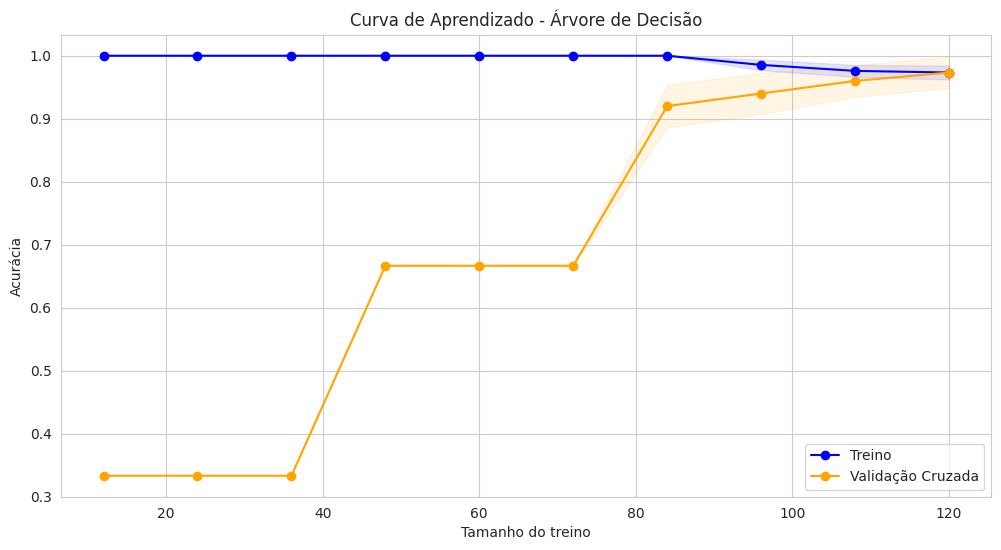

In [17]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    modelo, X_iris, y_iris, cv = 5, scoring = 'accuracy',
    train_sizes = np.linspace(0.1, 1.0, 10), random_state = 42,
)

train_mean = np.mean(train_scores, axis = 1)
train_std = np.std(train_scores, axis = 1)
test_mean = np.mean(test_scores, axis = 1)
test_std = np.std(test_scores, axis = 1)

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Treino')
plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Validação Cruzada')
plt.xlabel('Tamanho do treino')
plt.ylabel('Acurácia')
plt.title('Curva de Aprendizado - Árvore de Decisão')
plt.legend()
plt.show()

Interpretação :
- Se as curvas de treino e validação convergem para um valor alto e proximo, o modelo tem bom ajuste
- Se a curva de treino está muito acima da de validação, há overfitting
- Se ambas são baixas, underfitting

## Data augumentation para dados tabulares

Data augumentation é a geração de novas amostras sintéticas a partir das existentes. É comum em imagens, mas tambem útil em dados tabulares, especialmente para lidar com classes desbalanceadas ou para aumentara a robustez do modelo.


### Smote e ADASYN
- SMOTE : Cria exemplos sintéticos da classe minoritária por interpolação entre um ponto e seus vizinhos mais próximos

- ADASYN : É similar, mas dá mais peso a pontos da classe minoritária que sao mais dificeis de classificar



Cuidado: SMOTE pode gerar amostras que cruzam a fronteira entre classes, aumentando o ruído. Use com moderação e valide com validação cruzada.

In [ ]:
# Instalar imbalanced-learn se necessário
!pip install -q imbalanced-learn


In [18]:

from imblearn.over_sampling import SMOTE, ADASYN

# Criando um desbalanceamento artificial no Iris (usando apenas duas classes)
X_bin = X_iris[y_iris != 2]
y_bin = y_iris[y_iris != 2]

# Reduzir a classe 0 para 20 amostras
mask = (y_bin == 0)
indices_0 = np.where(mask)[0]
remove = np.random.choice(indices_0, size=30, replace=False)
X_bin = np.delete(X_bin, remove, axis=0)
y_bin = np.delete(y_bin, remove)

print('Distribuição original:', np.bincount(y_bin))

smote = SMOTE(random_state=42)
X_res_smote, y_res_smote = smote.fit_resample(X_bin, y_bin)
print('Após SMOTE:', np.bincount(y_res_smote))

adasyn = ADASYN(random_state=42)
X_res_adasyn, y_res_adasyn = adasyn.fit_resample(X_bin, y_bin)
print('Após ADASYN:', np.bincount(y_res_adasyn))

Distribuição original: [20 50]
Após SMOTE: [50 50]


RuntimeError: Not any neigbours belong to the majority class. This case will induce a NaN case with a division by zero. ADASYN is not suited for this specific dataset. Use SMOTE instead.

### Adição de ruído gaussiano

Adicionar pequenas pertubações aleatórias (ruidos) às features pode aumentar a robustez do modelo, funcionando como uma forma de regularização.

Parâmetro scale: controla a intensidade do ruído. Deve ser pequeno o suficiente para não descaracterizar a amostra (ex: 1% a 5% do desvio padrão da feature).

In [19]:
def add_gaussian_noise(X, scale=0.01):
    noise = np.random.normal(loc=0, scale=scale, size=X.shape)
    return X + noise

X_aug = add_gaussian_noise(X_bin, scale=0.05)
X_combined = np.vstack([X_bin, X_aug])
y_combined = np.hstack([y_bin, y_bin])
print('Shape combinado:', X_combined.shape)

Shape combinado: (140, 4)


## Modelos clássicos de Machine Learning

Vamos explorar cada algoritmo com prufundidade: intuição, formulação matemática, hiperparametros, prós e contras e implementações


### Regressão Linear e Regularização(ridge, lasso, elasticnet)

**Regressão linear =** Assume que a relação entre features e target é linear:
  $\hat{y} = w_0 + w_1 x_1 + \dots + w_p x_p$

Os coeficientes são estimados minimizando asoma dos quadrados dos resíduos (MSE):

  $\min_{w} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$



**Ridge (l2) :** Adiciona a penalidade à soma dos quadrados coeficientes
  $\min_{w} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} w_j^2$

O parametro alpha contrala a regularização. Reduz a variancia, evitando overfitting.

**Lasso(l1) :** Penalidade pela soma dos valores absolutos:

$\min_{w} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |w_j|$


**ElasticNet :** combina L1 + l2:

$\min_{w} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
+ \alpha \rho \sum_{j=1}^{p} |w_j|
+ \frac{\alpha (1-\rho)}{2} \sum_{j=1}^{p} w_j^2$

In [20]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_housing, y_housing, test_size=0.2, random_state=42)

# Regressão Linear
lr = LinearRegression()
lr.fit(X_train_h, y_train_h)
y_pred_lr = lr.predict(X_test_h)
print('Linear Regression - R²: {:.3f}, RMSE: {:.3f}'.format(r2_score(y_test_h, y_pred_lr), np.sqrt(mean_squared_error(y_test_h, y_pred_lr))))

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_h, y_train_h)
y_pred_ridge = ridge.predict(X_test_h)
print('Ridge - R²: {:.3f}, RMSE: {:.3f}'.format(r2_score(y_test_h, y_pred_ridge), np.sqrt(mean_squared_error(y_test_h, y_pred_ridge))))

# Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_h, y_train_h)
y_pred_lasso = lasso.predict(X_test_h)
print('Lasso - R²: {:.3f}, RMSE: {:.3f}'.format(r2_score(y_test_h, y_pred_lasso), np.sqrt(mean_squared_error(y_test_h, y_pred_lasso))))
print('Número de coeficientes zerados:', np.sum(lasso.coef_ == 0))

# ElasticNet
en = ElasticNet(alpha=0.01, l1_ratio=0.5)
en.fit(X_train_h, y_train_h)
y_pred_en = en.predict(X_test_h)
print('ElasticNet - R²: {:.3f}, RMSE: {:.3f}'.format(r2_score(y_test_h, y_pred_en), np.sqrt(mean_squared_error(y_test_h, y_pred_en))))

Linear Regression - R²: 0.576, RMSE: 0.746
Ridge - R²: 0.576, RMSE: 0.746
Lasso - R²: 0.585, RMSE: 0.738
Número de coeficientes zerados: 0
ElasticNet - R²: 0.584, RMSE: 0.739


### KNN - k-nearest-neighboors

Intuição: Para classificar um novo ponto, olhamos para os K pontos mais próximos no espaço de features e votamos (ou calculamos a média, para regressão). A escolha da distância (Euclidiana, Manhattan, etc.) e do número K são cruciais.


Hiperparâmetros:

n_neighbors: número de vizinhos. K pequeno → baixo viés, alta variância; K grande → alto viés, baixa variância.


weights: 'uniform' (todos os vizinhos com mesmo peso) ou 'distance' (peso inversamente proporcional à distância).


metric: 'euclidean', 'manhattan', 'minkowski' (com p), etc.


Importância do escalonamento: Como KNN usa distâncias, features em escalas diferentes dominariam a métrica. Portanto, é essencial padronizar/normalizar

In [22]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Classificação com Iris
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris)

scaler = StandardScaler()
X_train_iris_scaled = scaler.fit_transform(X_train_iris)
X_test_iris_scaled = scaler.transform(X_test_iris)

knn_clf = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski', p=2)
knn_clf.fit(X_train_iris_scaled, y_train_iris)
y_pred_knn = knn_clf.predict(X_test_iris_scaled)
print('KNN Classifier - Acurácia: {:.2f}'.format(accuracy_score(y_test_iris, y_pred_knn)))

# Regressão com Housing
# X_train_h, X_test_h, y_train_h, y_test_h are already defined from a previous cell for Housing
scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_h_scaled, y_train_h)
y_pred_knn_reg = knn_reg.predict(X_test_h_scaled)
print('KNN Regressor - R²: {:.3f}'.format(r2_score(y_test_h, y_pred_knn_reg)))

KNN Classifier - Acurácia: 0.91
KNN Regressor - R²: 0.670


###  Árvores de Decisão  

**Intuição:**  
A árvore divide recursivamente o espaço de features em regiões, escolhendo a feature e o ponto de corte que melhor separam os dados (maximizando ganho de informação ou minimizando impureza).  
Cada folha contém uma predição (classe majoritária ou média).

---

### Critérios de divisão (Classificação)

###  Gini (Impureza de Gini)

\begin{equation}
G = 1 - \sum_{k=1}^{K} p_k^2
\end{equation}

- Mede a impureza do nó.
- Quanto menor o valor, mais “puro” o nó.

---

###  Entropia

\begin{equation}
H = - \sum_{k=1}^{K} p_k \log(p_k)
\end{equation}

- Baseada na teoria da informação.
- Também mede a impureza.
- Quanto menor, mais homogêneo o nó.

---

###  Critérios para Regressão

MSE (Erro Quadrático Médio)

\begin{equation}
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\end{equation}

MAE (Erro Absoluto Médio)

\begin{equation}
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
\end{equation}

---

Hiperparâmetros importantes

- **`max_depth`** → profundidade máxima da árvore (controla complexidade).  
- **`min_samples_split`** → número mínimo de amostras para dividir um nó.  
- **`min_samples_leaf`** → número mínimo de amostras em uma folha.  
- **`max_features`** → número de features consideradas a cada divisão.  

---

 Vantagens

- Fácil interpretação  
- Não requer escalonamento  
- Captura interações não lineares  

 Desvantagens

- Propensa a overfitting (se não houver poda)  
- Instável (pequenas mudanças nos dados podem gerar árvores diferentes)  

Árvore Decisão - Acurácia: 0.98


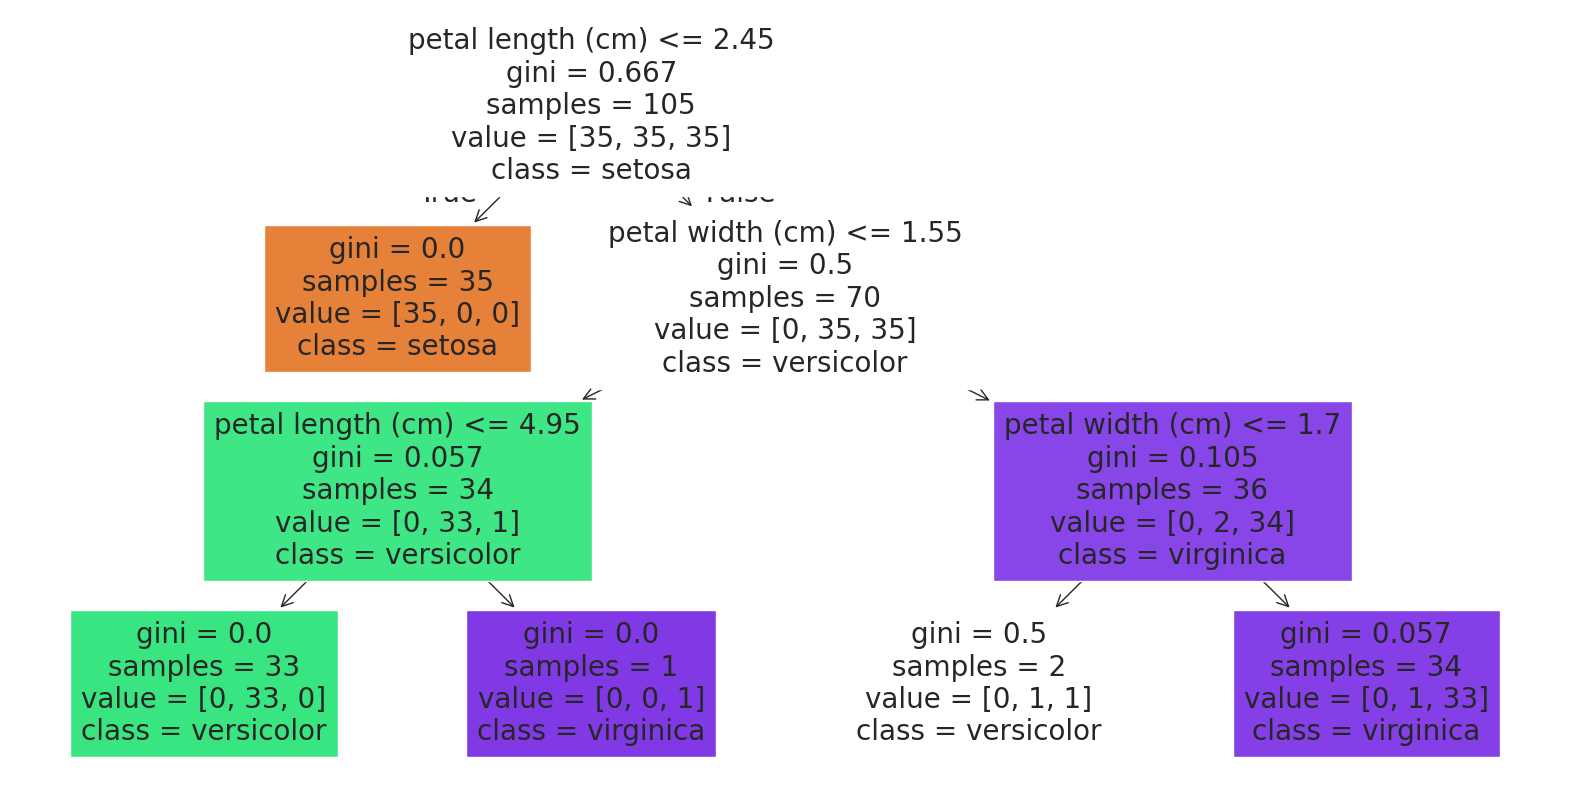

Árvore Regressão - R²: 0.600


In [23]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

# Classificação
dt_clf = DecisionTreeClassifier(max_depth=3, min_samples_split=10, random_state=42)
dt_clf.fit(X_train_iris, y_train_iris)
y_pred_dt = dt_clf.predict(X_test_iris)
print('Árvore Decisão - Acurácia: {:.2f}'.format(accuracy_score(y_test_iris, y_pred_dt)))

# Visualização
plt.figure(figsize=(20,10))
plot_tree(dt_clf, feature_names=feature_names_iris, class_names=target_names_iris, filled=True)
plt.show()

# Regressão
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train_h, y_train_h)
y_pred_dt_reg = dt_reg.predict(X_test_h)
print('Árvore Regressão - R²: {:.3f}'.format(r2_score(y_test_h, y_pred_dt_reg)))

### Support Vector Machine (SVM)

Intuição:  
O SVM encontra o hiperplano que melhor separa as classes, maximizando a margem (distância entre o hiperplano e os pontos mais próximos de cada classe – os vetores de suporte).  
Para dados não linearmente separáveis, utiliza-se o *kernel trick*, que mapeia os dados para um espaço de maior dimensão onde se tornam separáveis.

---

## Formulação do hiperplano

\begin{equation}
w \cdot x + b = 0
\end{equation}

Maximização da margem (forma simplificada):

\begin{equation}
\min_{w,b} \frac{1}{2} \|w\|^2
\end{equation}

Sujeito a:

\begin{equation}
y_i (w \cdot x_i + b) \geq 1, \quad i = 1, \dots, n
\end{equation}

---

## Kernels comuns

### Linear

\begin{equation}
K(x_i, x_j) = x_i \cdot x_j
\end{equation}

---

### Polinomial

\begin{equation}
K(x_i, x_j) = (\gamma x_i \cdot x_j + r)^d
\end{equation}

---

### RBF (Radial Basis Function)

\begin{equation}
K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)
\end{equation}

É o kernel mais utilizado na prática.

---

## Parâmetros importantes

**C**  
Controla a penalidade por erros de classificação.  

- C pequeno → margem maior, permite mais erros (mais regularização).  
- C grande → tenta classificar todos os pontos corretamente (pode overfittar).

**gamma (para RBF)**  
Controla o alcance do kernel.  

- gamma pequeno → ponto influencia uma região ampla (modelo mais suave).  
- gamma grande → influência restrita (modelo mais complexo).

---

## Importância do escalonamento

SVM é sensível à escala das variáveis.  
Sempre padronize os dados antes de treinar o modelo.

In [24]:
from sklearn.svm import SVC, SVR

# SVM Classifier
svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42)
svm_rbf.fit(X_train_iris_scaled, y_train_iris)
y_pred_svm = svm_rbf.predict(X_test_iris_scaled)
print('SVM RBF - Acurácia: {:.2f}'.format(accuracy_score(y_test_iris, y_pred_svm)))

# SVM Regressão
svr = SVR(kernel='rbf', C=1.0, gamma='scale')
svr.fit(X_train_h_scaled, y_train_h)
y_pred_svr = svr.predict(X_test_h_scaled)
print('SVR - R²: {:.3f}'.format(r2_score(y_test_h, y_pred_svr)))

SVM RBF - Acurácia: 0.93
SVR - R²: 0.728


## 6.5 Regressão Logística e Função Sigmóide

Apesar do nome, é um modelo de classificação. A regressão logística modela a probabilidade de uma instância pertencer a uma classe usando a função sigmoide:

$$
P(y=1 \mid x) = \sigma(w^T x) = \frac{1}{1 + e^{-w^T x}}
$$

A função sigmoide é definida como:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Para classificação binária, a decisão é tomada comparando a probabilidade com um limiar (geralmente 0.5):

$$
\hat{y} =
\begin{cases}
1, & \text{se } P(y=1 \mid x) \geq 0.5 \\
0, & \text{caso contrário}
\end{cases}
$$

Para problemas multiclasse, utiliza-se a função softmax (Regressão Logística Multinomial):

$$
P(y=k \mid x) =
\frac{e^{w_k^T x}}
{\sum_{j=1}^{K} e^{w_j^T x}}
$$

---

### Função de Custo: Log-Loss (Entropia Cruzada)

$$
J(w) =
- \frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i)
+
(1 - y_i)\log(1 - \hat{p}_i)
\right]
$$

onde:

$$
\hat{p}_i = \sigma(w^T x_i)
$$

---

### Regularização

#### Regularização L2 (Ridge)

$$
J(w) =
- \frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i)
+
(1 - y_i)\log(1 - \hat{p}_i)
\right]
+
\frac{\lambda}{2} \|w\|^2
$$

---

#### Regularização L1 (Lasso)

$$
J(w) =
- \frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i)
+
(1 - y_i)\log(1 - \hat{p}_i)
\right]
+
\lambda \sum_{j=1}^{p} |w_j|
$$

---

Relação entre o parâmetro de regularização:

$$
C = \frac{1}{\lambda}
$$

In [25]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200, C=1.0, random_state=42)
logreg.fit(X_train_iris_scaled, y_train_iris)
y_pred_logreg = logreg.predict(X_test_iris_scaled)
print('Regressão Logística - Acurácia: {:.2f}'.format(accuracy_score(y_test_iris, y_pred_logreg)))

# Probabilidades
probs = logreg.predict_proba(X_test_iris_scaled[:5])
print('Probabilidades previstas:\n', probs)

Regressão Logística - Acurácia: 0.91
Probabilidades previstas:
 [[3.28358312e-05 1.01448072e-01 8.98519092e-01]
 [1.41182995e-02 7.89437074e-01 1.96444626e-01]
 [3.58121931e-03 6.20192330e-01 3.76226450e-01]
 [2.18102444e-02 6.29198388e-01 3.48991368e-01]
 [5.15171433e-03 3.84550988e-01 6.10297298e-01]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Naive Bayes

Baseia-se no teorema de Bayes com a suposição "ingênua" de que as features são independentes dado a classe. Apesar da suposição frequentemente falsa, o modelo funciona bem em muitas tarefas (classificação de texto, filtros de spam).

Variantes:

**GaussianNB**: assume que as features seguem distribuição normal (para dados contínuos).

**MultinomialNB**: adequado para dados de contagem (ex: frequência de palavras).

**BernoulliNB**: para features binárias.

In [26]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_iris, y_train_iris)  # não precisa escalonar
y_pred_gnb = gnb.predict(X_test_iris)
print('GaussianNB - Acurácia: {:.2f}'.format(accuracy_score(y_test_iris, y_pred_gnb)))

GaussianNB - Acurácia: 0.91


### Random Forest

Intuição: Random Forest é um conjunto (ensemble) de árvores de decisão, cada uma treinada em uma amostra bootstrap dos dados (bagging) e considerando apenas um subconjunto aleatório das features em cada divisão. A predição final é a média (regressão) ou o voto majoritário (classificação) das árvores.

Vantagens: Alta precisão, robusto a overfitting (comparado a uma única árvore), lida bem com dados não lineares, fornece importância das features.

Hiperparâmetros:

n_estimators: número de árvores.

max_depth: profundidade máxima (se None, árvores crescem até folhas puras).

min_samples_split, min_samples_leaf: como em árvores.

max_features: número de features consideradas em cada divisão (padrão: sqrt para classificação, n_features para regressão).

bootstrap: se usa amostragem com reposição.



Random Forest - Acurácia: 0.89


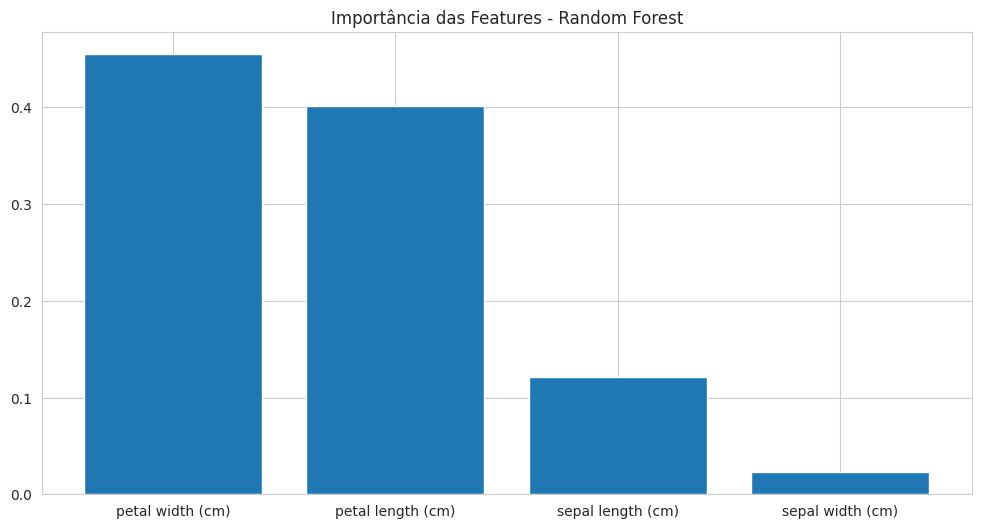

In [27]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf.fit(X_train_iris, y_train_iris)
y_pred_rf = rf_clf.predict(X_test_iris)
print('Random Forest - Acurácia: {:.2f}'.format(accuracy_score(y_test_iris, y_pred_rf)))

# Importância das features
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names_iris[i] for i in indices])
plt.title('Importância das Features - Random Forest')
plt.show()

### Gradient Boosting

Intuição: Gradient Boosting constrói árvores sequencialmente, onde cada nova árvore tenta corrigir os erros da combinação anterior. O modelo final é a soma ponderada de todas as árvores. Diferente do Random Forest (bagging), o boosting é sequencial e foca nos erros.

XGBoost: implementação otimizada, com regularização, suporte a missing values, paralelização, e é muito usado em competições.

LightGBM: ainda mais rápido e eficiente, com técnicas como Gradient-Based One-Side Sampling (GOSS) e Exclusive Feature Bundling (EFB).

In [28]:
# Instalar xgboost se necessário: !pip install xgboost
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train_iris, y_train_iris)
y_pred_xgb = xgb_clf.predict(X_test_iris)
print('XGBoost - Acurácia: {:.2f}'.format(accuracy_score(y_test_iris, y_pred_xgb)))

# LightGBM: !pip install lightgbm
import lightgbm as lgb
lgb_clf = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
lgb_clf.fit(X_train_iris, y_train_iris)
y_pred_lgb = lgb_clf.predict(X_test_iris)
print('LightGBM - Acurácia: {:.2f}'.format(accuracy_score(y_test_iris, y_pred_lgb)))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:15:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost - Acurácia: 0.93
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 83
[LightGBM] [Info] Number of data points in the train set: 105, number of used features: 4
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Avaliação de modelos

A avaliação deve ser feita no conjunto de teste( nunca usado durante o treinamento/validação)

## Métricas de Avaliação

### Acurácia
Proporção de classificações corretas em relação ao total de amostras:

$$
\text{Acurácia} = \frac{VP + VN}{VP + VN + FP + FN}
$$

Cuidado: pode ser enganosa em datasets desbalanceados.

---

### Precisão
Dentre os exemplos classificados como positivos, quantos realmente são positivos:

$$
\text{Precisão} = \frac{VP}{VP + FP}
$$

---

### Recall (Sensibilidade)
Dentre os positivos reais, quantos foram corretamente identificados:

$$
\text{Recall} = \frac{VP}{VP + FN}
$$

---

### F1-score
Média harmônica entre precisão e recall:

$$
F1 = 2 \cdot \frac{\text{Precisão} \cdot \text{Recall}}
{\text{Precisão} + \text{Recall}}
$$

---

### Especificidade
Dentre os negativos reais, quantos foram corretamente identificados:

$$
\text{Especificidade} = \frac{VN}{VN + FP}
$$

---

### Curva ROC e AUC

A curva ROC representa a relação entre:

- Taxa de Verdadeiros Positivos (TPR):

$$
TPR = \frac{VP}{VP + FN}
$$

- Taxa de Falsos Positivos (FPR):

$$
FPR = \frac{FP}{FP + VN}
$$

A AUC (Area Under the Curve) mede a capacidade do modelo de distinguir entre as classes.

---

### Multiclasse

Para problemas multiclasse, as métricas podem ser calculadas como:

- **Macro**: média simples das métricas por classe.
- **Weighted**: média ponderada pelo número de amostras (suporte) de cada classe.

Acurácia: 0.8888888888888888
Precisão macro: 0.898148148148148
Recall macro: 0.8888888888888888
F1 macro: 0.8877665544332212

Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



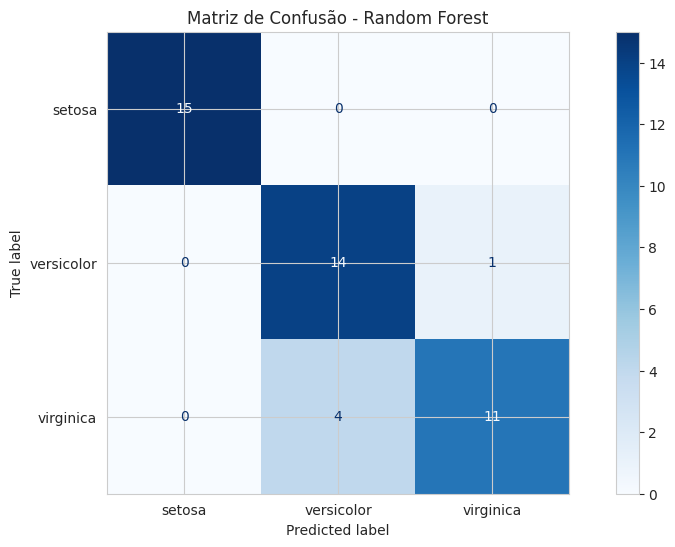

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# Usando Random Forest no teste
y_pred = rf_clf.predict(X_test_iris)
y_proba = rf_clf.predict_proba(X_test_iris)

print('Acurácia:', accuracy_score(y_test_iris, y_pred))
print('Precisão macro:', precision_score(y_test_iris, y_pred, average='macro'))
print('Recall macro:', recall_score(y_test_iris, y_pred, average='macro'))
print('F1 macro:', f1_score(y_test_iris, y_pred, average='macro'))

print('\nRelatório de Classificação:')
print(classification_report(y_test_iris, y_pred, target_names=target_names_iris))

# Matriz de confusão
cm = confusion_matrix(y_test_iris, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names_iris)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

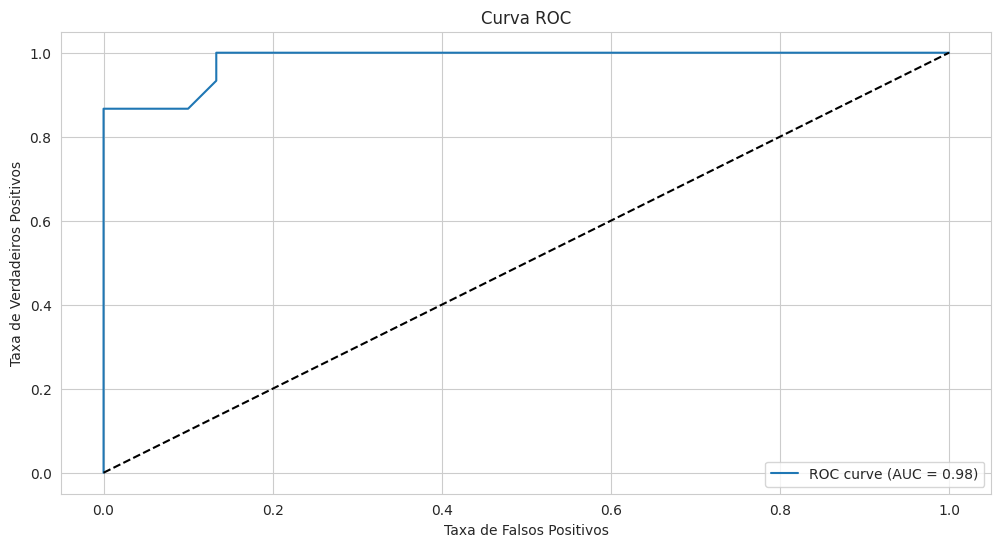

In [30]:
## Curva ROC, muito utilizada em classificação binária
# Binarizando: classe 1 vs resto
y_bin = (y_iris == 1).astype(int)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_iris, y_bin, test_size=0.3, random_state=42, stratify=y_bin)

rf_bin = RandomForestClassifier(random_state=42)
rf_bin.fit(X_train_bin, y_train_bin)
y_proba_bin = rf_bin.predict_proba(X_test_bin)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_bin, y_proba_bin)
auc = roc_auc_score(y_test_bin, y_proba_bin)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()



## Métricas de Regressão

### MAE (Mean Absolute Error)

Erro absoluto médio. É interpretável na mesma unidade do target.

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

---

### MSE (Mean Squared Error)

Erro quadrático médio. Penaliza mais erros grandes.

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

---

### RMSE (Root Mean Squared Error)

Raiz quadrada do MSE. Também está na mesma unidade do target.

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

ou simplesmente:

$$
RMSE = \sqrt{MSE}
$$

---

### R² (Coeficiente de Determinação)

Representa a proporção da variância explicada pelo modelo.

$$
R^2 = 1 -
\frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

Pode ser negativo se o modelo for pior do que simplesmente prever a média.

---

### MAPE (Mean Absolute Percentage Error)

Erro percentual absoluto médio. Deve-se ter cuidado quando $y_i = 0$.

$$
MAPE = \frac{1}{n} \sum_{i=1}^{n}
\left|
\frac{y_i - \hat{y}_i}{y_i}
\right|
$$

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Instantiate and train RandomForestRegressor
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_h, y_train_h)

y_pred_rf_reg = rf_reg.predict(X_test_h)

print('MAE:', mean_absolute_error(y_test_h, y_pred_rf_reg))
print('MSE:', mean_squared_error(y_test_h, y_pred_rf_reg))
print('RMSE:', np.sqrt(mean_squared_error(y_test_h, y_pred_rf_reg)))
print('R²:', r2_score(y_test_h, y_pred_rf_reg))

MAE: 0.32754256845930246
MSE: 0.2553684927247781
RMSE: 0.5053399773665033
R²: 0.8051230593157366


### Curvas de Precisão-Revocação

Úteis quando há desbalanceamento. Mostram o trade-off entre precisão e recall para diferentes limiares.

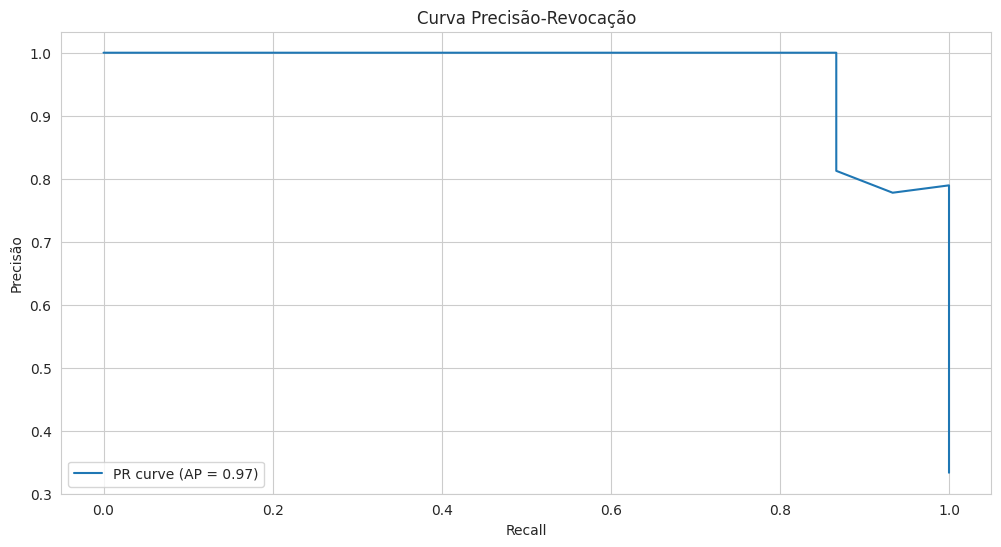

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test_bin, y_proba_bin)
ap = average_precision_score(y_test_bin, y_proba_bin)

plt.plot(recall, precision, label=f'PR curve (AP = {ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precisão-Revocação')
plt.legend()
plt.show()

### Gráficos de residuos e análise de erros

Para regressão, plotar os resíduos (erros) versus valores previstos ajuda a detectar heterocedasticidade ou não linearidade.



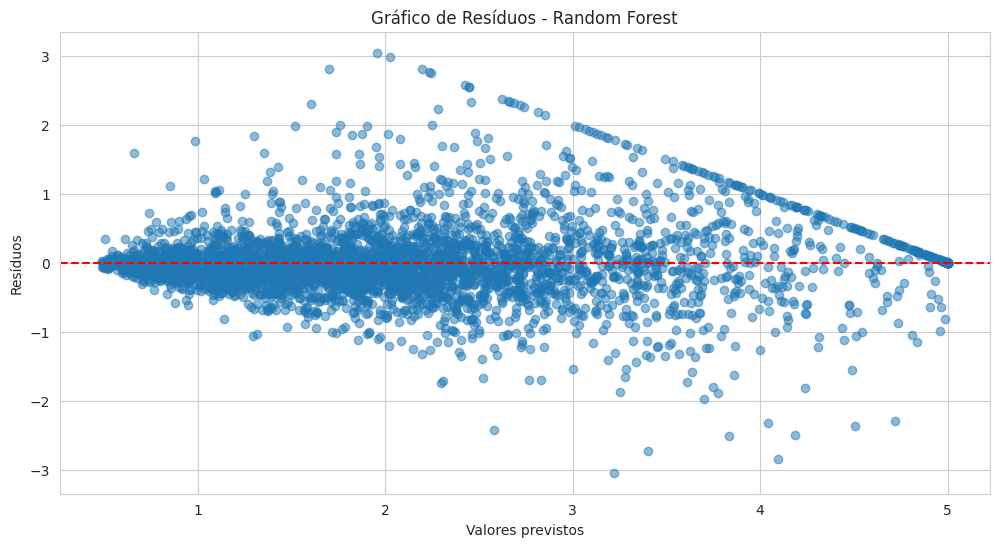

In [34]:
residuos = y_test_h - y_pred_rf_reg
plt.scatter(y_pred_rf_reg, residuos, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores previstos')
plt.ylabel('Resíduos')
plt.title('Gráfico de Resíduos - Random Forest')
plt.show()

## Otimização de hiperparametros

Hiperparâmetros são parâmetros que não são aprendidos durante o treinamento, mas definidos antes. Ajustá-los corretamente pode melhorar significativamente o desempenho.

### Grid Search com Validação cruzada

O Grid Search testa exaustivamente todas as combinações de valores fornecidos em um grid. Com a validação cruzada, estima o desempenho para cada combinação e escolhe a melhor.

-> Essa combinação é bastante utilizada. Recomendo sempre que voces pegarem um modelo, caso tenha maquina, rodar essa combinção.

In [35]:
from sklearn.model_selection import GridSearchCV

# Definindo o modelo e o grid de parâmetros
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_iris, y_train_iris)

print('Melhores parâmetros:', grid_search.best_params_)
print('Melhor acurácia (CV):', grid_search.best_score_)

# Avaliar no teste
y_pred_grid = grid_search.predict(X_test_iris)
print('Acurácia no teste:', accuracy_score(y_test_iris, y_pred_grid))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores parâmetros: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100}
Melhor acurácia (CV): 0.9619047619047618
Acurácia no teste: 0.9111111111111111


### Random Search

Em vez de testar todas as combinações. O random search amostra aleatoriametnte um numero fixo de combinações a partir de distribuições. É mais eficientequando  o espaço de busca é grande.


In [36]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None] + list(randint(3, 10).rvs(5)),
    'min_samples_split': randint(2, 11),
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(rf, param_dist, n_iter=30, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(X_train_iris, y_train_iris)

print('Melhores parâmetros:', random_search.best_params_)
print('Melhor acurácia (CV):', random_search.best_score_)

Melhores parâmetros: {'max_depth': np.int64(6), 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 153}
Melhor acurácia (CV): 0.9619047619047618


### Integração: Pipeline titanic + grid Search



In [37]:
# Retomando o pipeline do Titanic
pipe_titanic = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Definindo grid de parâmetros para o classificador (e eventualmente para o pré-processamento)
param_grid_titanic = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5, 7],
    'preprocessor__num__imputer__strategy': ['mean', 'median']  # testar diferentes imputações
}

grid_titanic = GridSearchCV(pipe_titanic, param_grid_titanic, cv=5, scoring='accuracy', n_jobs=-1)
grid_titanic.fit(X_titanic, y_titanic)

print('Melhores parâmetros Titanic:', grid_titanic.best_params_)
print('Melhor acurácia (CV):', grid_titanic.best_score_)

Melhores parâmetros Titanic: {'classifier__max_depth': 7, 'classifier__n_estimators': 50, 'preprocessor__num__imputer__strategy': 'median'}
Melhor acurácia (CV): 0.8327788588286987


## Interpretabilidade dos modelos

Modelos complexos como RandomForest e XGBoost sao caixas pretas. técnicas de interpretabilidade ajudam a enender por que o modelo faz certas previsoes,

### Importancia das features

ja vimos para árvores. No randomForest, a importancia é calculada pela redução média da impureza (Gini ou MSE) proporcionada por cada feature em todas as árvores

In [38]:
importances = rf_clf.feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_names_iris, 'importance': importances}).sort_values('importance', ascending=False)
print(feature_importance_df)

             feature  importance
3   petal width (cm)    0.454769
2  petal length (cm)    0.401161
0  sepal length (cm)    0.121437
1   sepal width (cm)    0.022633


## Exercicio final

Objetivo: Aplicar todo o pipeline de Machine Learning em um problema real, com entrega de um relatório técnico.

Dataset: Escolha um dos seguintes (ou outro de interesse):

Titanic (classificação) – já trabalhado.

Heart Disease UCI (classificação) – disponível no Kaggle ou UCI.

Wine Quality (classificação ou regressão) – UCI.

Diabetes (regressão) – sklearn.datasets.load_diabetes().

Boston Housing (regressão) – fetch_openml('boston').


Tarefas:

Carregar e explorar (estatísticas, visualizações, correlações, outliers).

Pré-processar (tratar missing, codificar categóricas, criar features, selecionar features, escalonar).

Dividir em treino e teste (stratify se classificação).

Construir pipelines com ColumnTransformer para pelo menos 3 modelos (ex: Regressão Logística, Random Forest, XGBoost).

Otimizar hiperparâmetros com GridSearchCV ou RandomizedSearchCV para um dos modelos.

Avaliar no teste com métricas apropriadas (matriz de confusão, relatório, curva ROC, etc.) e gráficos.

Interpretar os resultados com importância de features, SHAP ou PDP.

Discutir overfitting/underfitting, trade-offs, possíveis melhorias.

Formato de entrega: Notebook executado compartilhado via GitHub.